 # 🏦 Credit Scorecard Development Pipeline



 **Goal**: Build a regulatory-grade scorecard (Points based on PDO) without data leakage.



 **Steps**:

 1. Data Loading & Strict Leakage Cleanup (+ EDA)

 2. Feature Engineering (+ EDA)

 3. Train/Test Split

 4. Weight of Evidence (WoE) Binning & Transformation

 5. Feature Selection (IV check & Correlation)

 6. Logistic Regression Modeling

 7. Model Evaluation (KS, Gini, AUC)

 8. Scorecard Scaling (Points, PDO)

 9. Calibration & Validation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
sns.set_style("whitegrid")


 ## 1. 🧹 Data Loading & Initial EDA

 **Target Definition**: 1 = Good, 0 = Bad.

In [4]:
# Load Data (Adjust path as needed)
# df = pd.read_csv('C:/Users/hungn/Downloads/ac.gz', compression='gzip', low_memory=False)
# For demonstration, using the file path from your previous context if available, otherwise assuming local:
df = pd.read_csv('ac.gz', compression='gzip', low_memory=False)
print(f"Initial dataset shape: {df.shape}")
# 1. Target Definition
loan_status_mapping = {
    'Fully Paid': 1,            
    'Current': 1,               
    'In Grace Period': 1,       
    'Late (16-30 days)': 0,     
    'Late (31-120 days)': 0,    
    'Charged Off': 0,           
    'Default': 0,
    'Does not meet the credit policy. Status:Fully Paid': 1,
    'Does not meet the credit policy. Status:Charged Off': 0                
}

# Apply mapping
df['loan_status_binary'] = df['loan_status'].map(loan_status_mapping)
df.dropna(subset=['loan_status_binary'], inplace=True)


Initial dataset shape: (2260701, 151)


 ### 📊 EDA 1: Target Distribution

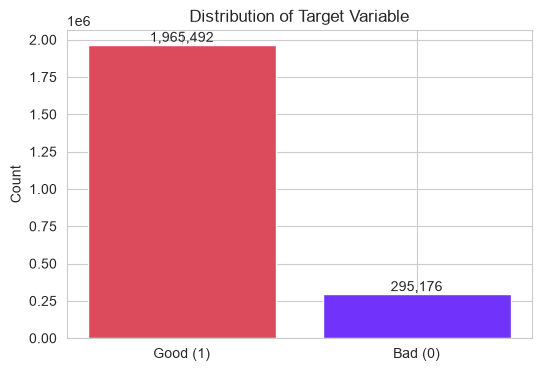

In [5]:
# PLOT: Target Distribution (Static)
target_counts = df['loan_status_binary'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Good (1)', 'Bad (0)'], [target_counts.get(1, 0), target_counts.get(0, 0)], color=['#dc4b5b', '#7132fb'])
plt.title('Distribution of Target Variable')
plt.ylabel('Count')
# Add counts on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{int(yval):,}', ha='center', va='bottom')
plt.show()


In [9]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Load LCDataDictionary and clean up column names
dict_df = pd.read_csv('LCDataDictionary.csv')
dict_cols = set(dict_df['LoanStatNew'].dropna().astype(str).str.strip())

# Extract columns from df
df_cols = set(df.columns.astype(str).str.strip())

# 1. Print full df columns
print(f"=== 1. Full DF Columns ({len(df.columns)}) ===")
print(list(df.columns))

# 2. Columns in DF but NOT in LCDataDictionary.csv
in_df_not_dict = sorted(list(df_cols - dict_cols))
print(f"\n=== 2. Columns in DF but NOT in LCDataDictionary.csv ({len(in_df_not_dict)}) ===")
print(in_df_not_dict)

# 3. Columns in LCDataDictionary.csv but NOT in DF
in_dict_not_df = sorted(list(dict_cols - df_cols))
print(f"\n=== 3. Columns in LCDataDictionary.csv but NOT in DF ({len(in_dict_not_df)}) ===")
print(in_dict_not_df)


=== 1. Full DF Columns (152) ===
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification

 ### 📋 EDA 2: General Statistics

In [4]:
print(f"Total Observations: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

# Missing Value Summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print("\nTop 10 Features with Missing Values:")
print(missing_summary.head(10))


Total Observations: 2,260,668
Total Features: 152

Top 10 Features with Missing Values:
member_id                                     2260668
orig_projected_additional_accrued_interest    2252017
hardship_dpd                                  2249751
hardship_payoff_balance_amount                2249751
hardship_reason                               2249751
hardship_type                                 2249751
hardship_amount                               2249751
hardship_start_date                           2249751
hardship_end_date                             2249751
payment_plan_start_date                       2249751
dtype: int64


 ### 🛑 Leakage Cleanup

 Removing features not available at the time of application.

In [5]:
leakage_cols = [
    # Payment & Outcome Tracking
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'pymnt_plan',
    # Current/Updated Borrower Info (Future Data)
    'last_fico_range_high', 'last_fico_range_low', 'last_credit_pull_d',
    # Hardship & Settlement
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',
    'loan_status', 'url', 'id', 'member_id'
]

cols_to_drop = [col for col in leakage_cols if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} leakage columns.")


Dropped 42 leakage columns.


 ## 2. 🛠️ Feature Engineering & EDA

In [6]:
# 1. Date Processing
print("Processing Dates...")
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')


Processing Dates...


 ### 📈 EDA 3: Temporal Analysis (Loan Volume)

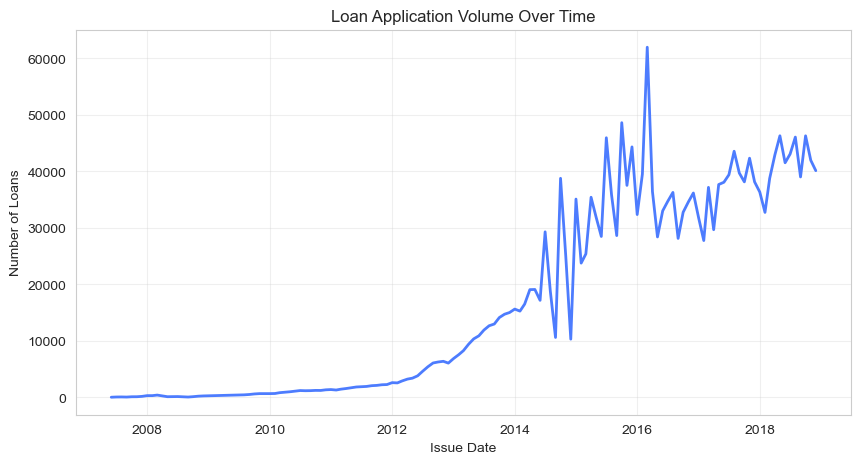

In [7]:
# PLOT: Loan Volume Over Time
volume_by_time = df.groupby('issue_d').size()
plt.figure(figsize=(10, 5))
plt.plot(volume_by_time.index, volume_by_time.values, color='#4d7cfe', linewidth=2)
plt.title('Loan Application Volume Over Time')
plt.xlabel('Issue Date')
plt.ylabel('Number of Loans')
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# 2. Calculate Credit History Length
df.dropna(subset=['earliest_cr_line', 'issue_d'], inplace=True)
df['credit_hist_months'] = ((df['issue_d'] - df['earliest_cr_line']).dt.days / 30.4375).astype(int)

# 3. Drop issue_d (Leakage/Identifier prevention)
df.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

# 4. Numeric conversions
df['emp_length'] = df['emp_length'].fillna('< 1 year').astype(str)
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').fillna(0).astype(int)

if 'term' in df.columns:
    df['term_int'] = df['term'].str.extract(r'(\d+)').astype(float)
    df.drop('term', axis=1, inplace=True)

# 5. Fill Missing Values (Simple imputation)
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values filled.")


Missing values filled.


 ### 📊 EDA 4: Categorical Feature Analysis (Grade)

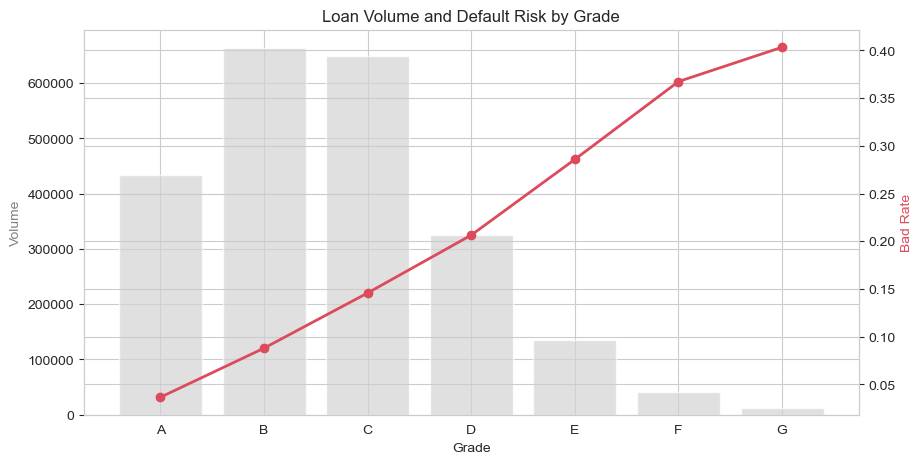

In [9]:
# PLOT: Volume vs Bad Rate by Grade
if 'grade' in df.columns:
    grade_stats = df.groupby('grade')['loan_status_binary'].agg(['count', 'mean']).reset_index()
    grade_stats['bad_rate'] = 1 - grade_stats['mean'] 
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Bar chart (Volume)
    ax1.bar(grade_stats['grade'], grade_stats['count'], color='lightgray', alpha=0.7, label='Volume')
    ax1.set_xlabel('Grade')
    ax1.set_ylabel('Volume', color='gray')
    
    # Line chart (Bad Rate)
    ax2 = ax1.twinx()
    ax2.plot(grade_stats['grade'], grade_stats['bad_rate'], color='#dc4b5b', marker='o', linewidth=2, label='Bad Rate')
    ax2.set_ylabel('Bad Rate', color='#dc4b5b')
    
    plt.title('Loan Volume and Default Risk by Grade')
    plt.show()


 ## 3. ✂️ Train / Test Split

In [10]:
X = df.drop(['loan_status_binary'], axis=1, errors='ignore')
y = df['loan_status_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (1582447, 108), Test size: (678192, 108)


 ## 4. 🧠 Automated WoE Transformation

In [11]:
class WoE_Binning:
    def __init__(self, max_bins=5, min_samples=0.05):
        self.max_bins = max_bins
        self.min_samples = min_samples
        self.woe_maps = {}
        self.iv_values = {}
        
    def fit(self, X, y):
        for col in X.columns:
            if pd.api.types.is_numeric_dtype(X[col]):
                dt = DecisionTreeClassifier(max_leaf_nodes=self.max_bins, min_samples_leaf=self.min_samples, random_state=42)
                dt.fit(X[[col]], y)
                thresholds = np.sort(dt.tree_.threshold[dt.tree_.threshold != -2])
                bins = [-np.inf] + list(thresholds) + [np.inf]
                self._calculate_woe(X[col], y, col, bins=bins, is_numeric=True)
            else:
                self._calculate_woe(X[col], y, col, is_numeric=False)
                
    def _calculate_woe(self, feature_series, target, col_name, bins=None, is_numeric=True):
        df_temp = pd.DataFrame({'feature': feature_series, 'target': target})
        if is_numeric:
            df_temp['bin'] = pd.cut(df_temp['feature'], bins=bins, duplicates='drop')
        else:
            df_temp['bin'] = df_temp['feature']
            
        grouped = df_temp.groupby('bin', observed=False)['target'].agg(['count', 'sum'])
        grouped['good'] = grouped['sum']
        grouped['bad'] = grouped['count'] - grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        grouped['dist_good'] = (grouped['good'] + 0.5) / total_good
        grouped['dist_bad'] = (grouped['bad'] + 0.5) / total_bad
        grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
        grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
        
        self.woe_maps[col_name] = grouped['woe'].to_dict()
        self.iv_values[col_name] = grouped['iv'].sum()
        if is_numeric:
            self.woe_maps[col_name]['bins'] = bins

    def transform(self, X):
        X_woe = X.copy()
        for col in self.woe_maps:
            mapping = self.woe_maps[col]
            if 'bins' in mapping:
                bins = mapping['bins']
                binned_series = pd.cut(X[col], bins=bins, duplicates='drop')
                X_woe[col] = binned_series.map(mapping).astype(float)
            else:
                X_woe[col] = X[col].map(mapping).fillna(0).astype(float)
        return X_woe

# Initialize and Fit
woe_encoder = WoE_Binning(max_bins=6, min_samples=0.05)
woe_encoder.fit(X_train, y_train)

# Transform
X_train_woe = woe_encoder.transform(X_train)
X_test_woe = woe_encoder.transform(X_test)
print("WoE Transformation complete.")


WoE Transformation complete.


 ### 📉 EDA 5: WoE Visualization

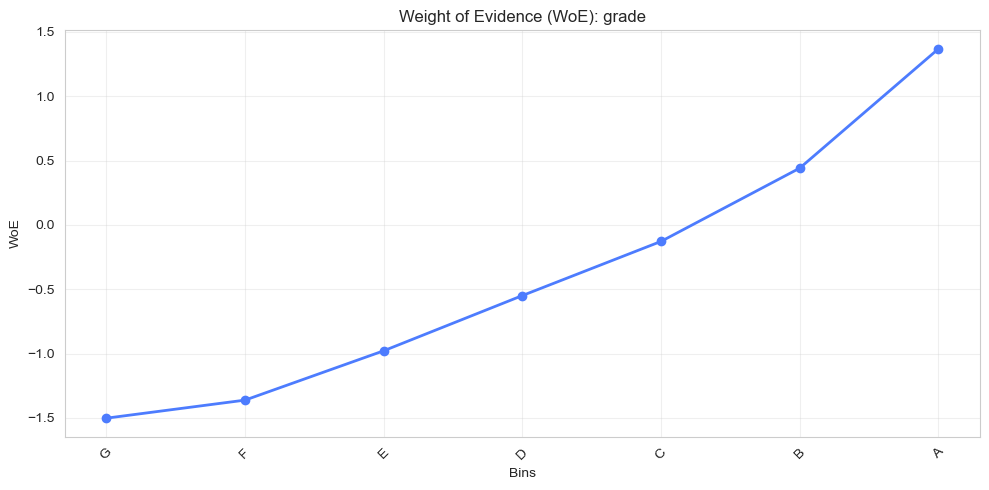

In [12]:
# PLOT: WoE by Bin for a selected feature (e.g., 'grade' or top IV feature)
def plot_woe_static(feature_name):
    if feature_name not in woe_encoder.woe_maps:
        return
    
    mapping = woe_encoder.woe_maps[feature_name]
    if 'bins' in mapping:
         # Numeric: Keys are Intervals, we need to convert to string for plotting
        keys = [str(k) for k in mapping.keys() if k != 'bins']
        values = [mapping[k] for k in mapping.keys() if k != 'bins']
    else:
        # Categorical
        keys = list(mapping.keys())
        values = list(mapping.values())
        
    # Sort by WoE for better visualization
    plot_data = pd.DataFrame({'bin': keys, 'woe': values}).sort_values('woe')
    
    plt.figure(figsize=(10, 5))
    plt.plot(plot_data['bin'], plot_data['woe'], marker='o', linestyle='-', color='#4d7cfe', linewidth=2)
    plt.title(f'Weight of Evidence (WoE): {feature_name}')
    plt.xlabel('Bins')
    plt.ylabel('WoE')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot 'grade' if it exists, otherwise the feature with highest IV
if 'grade' in X_train.columns:
    plot_woe_static('grade')
else:
    top_feature = max(woe_encoder.iv_values, key=woe_encoder.iv_values.get)
    plot_woe_static(top_feature)


 ## 5. 🔍 Feature Selection & Correlation

In [13]:
# 1. IV Selection
iv_df = pd.DataFrame.from_dict(woe_encoder.iv_values, orient='index', columns=['IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
selected_features = iv_df[(iv_df['IV'] >= 0.02) & (iv_df['IV'] <= 0.6)].index.tolist()
print(f"Features selected by IV: {len(selected_features)}")


Features selected by IV: 51


 ### 🔥 EDA 6: Correlation Heatmap

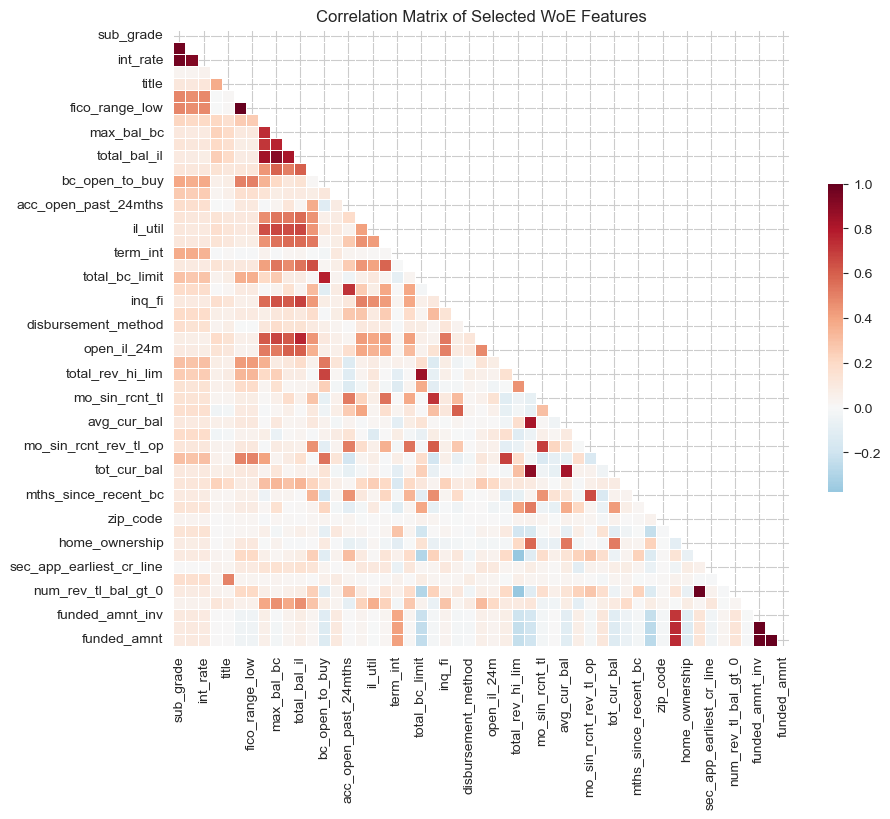

In [14]:
# PLOT: Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = X_train_woe[selected_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix of Selected WoE Features')
plt.show()


In [15]:
# 2. Drop Correlated Features
def drop_correlated_features(df_woe, iv_df, threshold=0.7):
    corr_matrix = df_woe.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = set()
    
    for col in upper_tri.columns:
        correlated_cols = upper_tri.index[upper_tri[col] > threshold].tolist()
        for row in correlated_cols:
            iv_col = iv_df.loc[col, 'IV']
            iv_row = iv_df.loc[row, 'IV']
            if iv_col > iv_row:
                to_drop.add(row)
            else:
                to_drop.add(col)
    return list(to_drop)

features_to_drop = drop_correlated_features(X_train_woe[selected_features], iv_df)
final_features = [f for f in selected_features if f not in features_to_drop]

print(f"Dropped {len(features_to_drop)} correlated features.")
print(f"Final Model Features: {len(final_features)}")

X_train_final = X_train_woe[final_features]
X_test_final = X_test_woe[final_features]


Dropped 17 correlated features.
Final Model Features: 34


 ## 6. 📉 Logistic Regression Modeling

In [16]:
model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, class_weight='balanced')
model.fit(X_train_final, y_train)
y_pred_proba = model.predict_proba(X_test_final)[:, 1]
print(f"Model Intercept: {model.intercept_[0]:.4f}")


Model Intercept: 0.0773


 ## 7. 📏 Model Evaluation

AUC : 0.7213
Gini: 0.4426
KS  : 0.3184


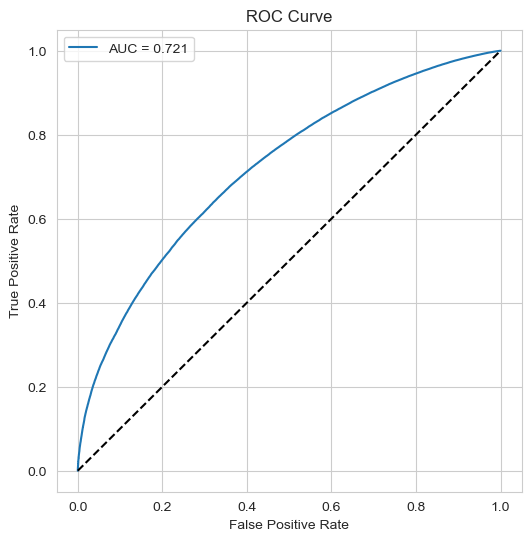

In [17]:
# ROC Curve & AUC
auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ks = max(tpr - fpr)

print(f"AUC : {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS  : {ks:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


 ## 8. 💳 Scorecard Scaling (PDO)

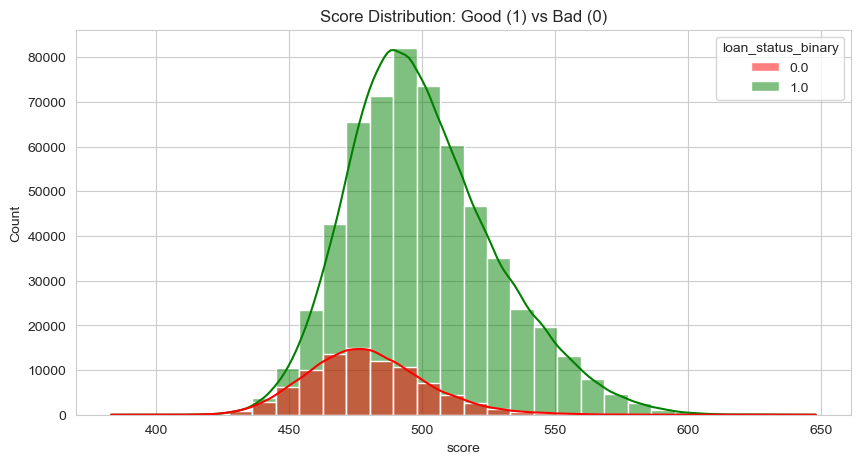

In [18]:
PDO = 20
Base_Score = 600
Base_Odds = 50

Factor = PDO / np.log(2)
Offset = Base_Score - (Factor * np.log(Base_Odds))

# Calculate Log-Odds (Logit)
intercept = model.intercept_[0]
coefs = model.coef_[0]

# Vectorized Score Calculation
X_test_final['logit'] = intercept + np.dot(X_test_final[final_features], coefs.T)
X_test_final['score'] = Offset + (Factor * X_test_final['logit'])
X_test_final['score'] = X_test_final['score'].astype(int)

# Score Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(data=X_test_final, x='score', hue=y_test, bins=30, kde=True, palette={0:'red', 1:'green'})
plt.title('Score Distribution: Good (1) vs Bad (0)')
plt.show()


 ## 9. ⚖️ Calibration (Isotonic Regression)

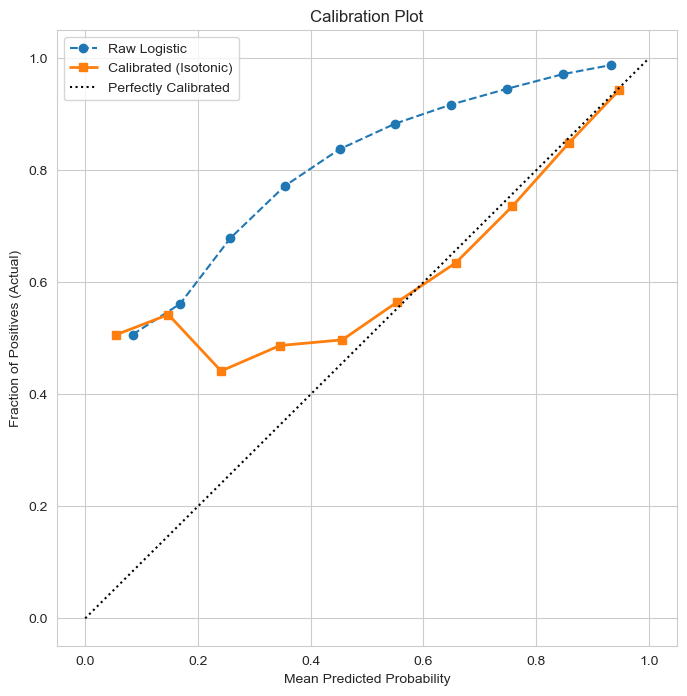

Calibration Complete. Added 'calibrated_pd' to test set.


In [19]:
# 1. Train Calibrator (Isotonic)
# Note: Typically done on a validation set, here using training set for demonstration
iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
y_train_proba = model.predict_proba(X_train_final)[:, 1]
iso_reg.fit(y_train_proba, y_train)

# 2. Calibrate Test Probabilities
y_test_calibrated = iso_reg.predict(y_pred_proba)

# 3. Calibration Plot (Reliability Diagram)
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_pred_proba, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_test_calibrated, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw Logistic', linestyle='--')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Calibrated (Isotonic)', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Plot')
plt.legend()
plt.show()

# 4. Save Calibrated PD
X_test_final['calibrated_pd'] = 1 - y_test_calibrated
print("Calibration Complete. Added 'calibrated_pd' to test set.")